In [15]:
import json
import pandas as pd

# Load JSON data
with open('1Site/new_traces.json') as f:
    data = json.load(f)

results = []

# Process each trace
for trace in data['data']:
    trace_id = trace['traceID']
    spans = trace['spans']

    # Check there are at least 7 spans to access indices 0 and 6
    if len(spans) >= 7:
        span1_us = spans[0]['duration']   # duration in microseconds
        span6_us = spans[6]['duration']
        total_us = span1_us + span6_us

        # Convert durations from microseconds to milliseconds
        results.append({
            'traceID': trace_id,
            'trigger_ms': span1_us / 1000,
            'dispatcher_ms': span6_us / 1000,
            'total_duration_ms': total_us / 1000
        })

# Create a pandas DataFrame from the results
df = pd.DataFrame(results)

# Print the DataFrame
df


,traceID,trigger_ms,dispatcher_ms,total_duration_ms
0,ec06578b19b649abe6d8c1b53a6a912d,2.847,2.810,5.657
1,16c3ee5c3482c5ba1bf75cc6403bc41c,2.875,3.521,6.396
2,56eec63a6e9d47a5a1f561dda089fba0,4.639,1.699,6.338
3,e155c88aeafcbfbd75bd068c13c5c058,3.006,1.574,4.580
4,cbdb203ed7cf7f6a76118f085717e9fd,3.439,2.429,5.868
...,...,...,...,...
195,323d319fd8339fd262575de6558dee43,3.485,1.129,4.614
196,142d9c61474b58d53887c843e164928e,3.038,1.165,4.203
197,7dbd144c87784844c4b30bb2c55a7a17,3.012,1.536,4.548
198,69f860d678d2891572461df5422c989f,1.816,1.090,2.906


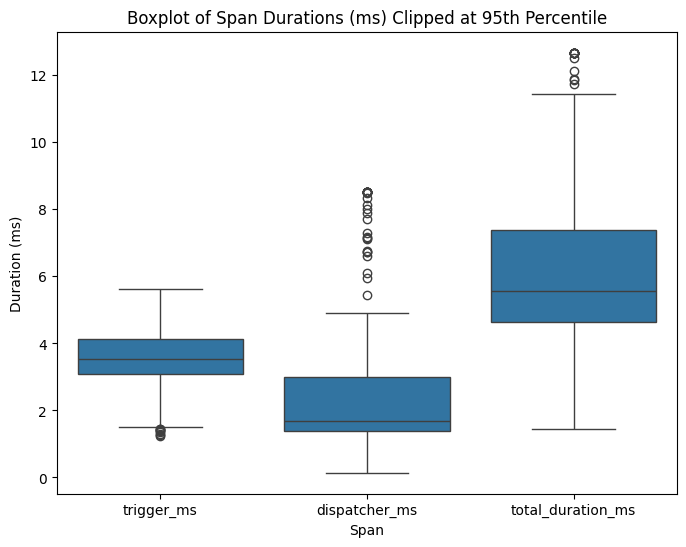

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate 95th percentile for each duration column
p95_span1 = np.percentile(df['trigger_ms'], 95)
p95_span6 = np.percentile(df['dispatcher_ms'], 95)
p95_total = np.percentile(df['total_duration_ms'], 95)

# Filter rows by clipping durations at 95th percentile
df_filtered = df.copy()
df_filtered['trigger_ms'] = np.minimum(df['trigger_ms'], p95_span1)
df_filtered['dispatcher_ms'] = np.minimum(df['dispatcher_ms'], p95_span6)
df_filtered['total_duration_ms'] = np.minimum(df['total_duration_ms'], p95_total)

# Melt filtered data for seaborn
df_melted = df_filtered.melt(id_vars='traceID', 
                             value_vars=['trigger_ms', 'dispatcher_ms', 'total_duration_ms'],
                             var_name='Span', value_name='Duration_ms')

plt.figure(figsize=(8,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.title('Boxplot of Span Durations (ms) Clipped at 95th Percentile')
plt.ylabel('Duration (ms)')
plt.xlabel('Span')
plt.show()


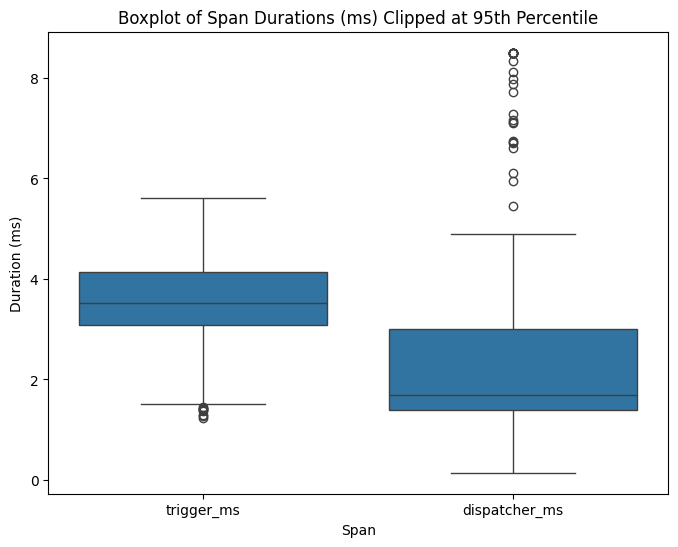

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate 95th percentile for each duration column
p95_span1 = np.percentile(df['trigger_ms'], 95)
p95_span6 = np.percentile(df['dispatcher_ms'], 95)
p95_total = np.percentile(df['total_duration_ms'], 95)

# Filter rows by clipping durations at 95th percentile
df_filtered = df.copy()
df_filtered['trigger_ms'] = np.minimum(df['trigger_ms'], p95_span1)
df_filtered['dispatcher_ms'] = np.minimum(df['dispatcher_ms'], p95_span6)
df_filtered['total_duration_ms'] = np.minimum(df['total_duration_ms'], p95_total)

# Melt filtered data for seaborn, excluding 'total_duration_ms'
df_melted = df_filtered.melt(id_vars='traceID', 
                             value_vars=['trigger_ms', 'dispatcher_ms'],  # exclude total_duration_ms here
                             var_name='Span', value_name='Duration_ms')

plt.figure(figsize=(8,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.title('Boxplot of Span Durations (ms) Clipped at 95th Percentile')
plt.ylabel('Duration (ms)')
plt.xlabel('Span')
plt.show()


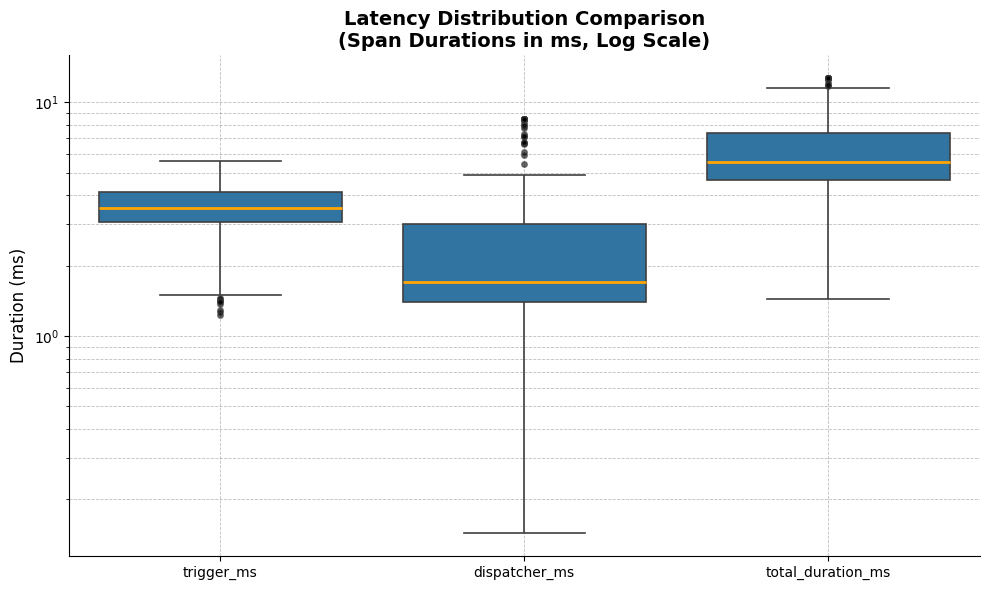

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter data by clipping at 95th percentile as before
p95_span1 = np.percentile(df['trigger_ms'], 95)
p95_span6 = np.percentile(df['dispatcher_ms'], 95)
p95_total = np.percentile(df['total_duration_ms'], 95)

df_filtered = df.copy()
df_filtered['trigger_ms'] = np.minimum(df['trigger_ms'], p95_span1)
df_filtered['dispatcher_ms'] = np.minimum(df['dispatcher_ms'], p95_span6)
df_filtered['total_duration_ms'] = np.minimum(df['total_duration_ms'], p95_total)

df_melted = df_filtered.melt(id_vars='traceID', 
                             value_vars=['trigger_ms', 'dispatcher_ms', 'total_duration_ms'],
                             var_name='Span', value_name='Duration_ms')

plt.figure(figsize=(10,6))

# Create the boxplot with Seaborn
sns.boxplot(x='Span', y='Duration_ms', data=df_melted,
            boxprops=dict(linewidth=1.2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            medianprops=dict(color='orange', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='black', markersize=4, alpha=0.6))

# Title and labels
plt.title('Latency Distribution Comparison\n(Span Durations in ms, Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Duration (ms)', fontsize=12)

# Log scale for y-axis
plt.yscale('log')

# Grid lines with dashed style and light gray color
plt.grid(True, which='both', linestyle='--', linewidth=0.6, color='gray', alpha=0.5)

# Remove top and right spines for cleaner look
sns.despine()

plt.tight_layout()
plt.show()


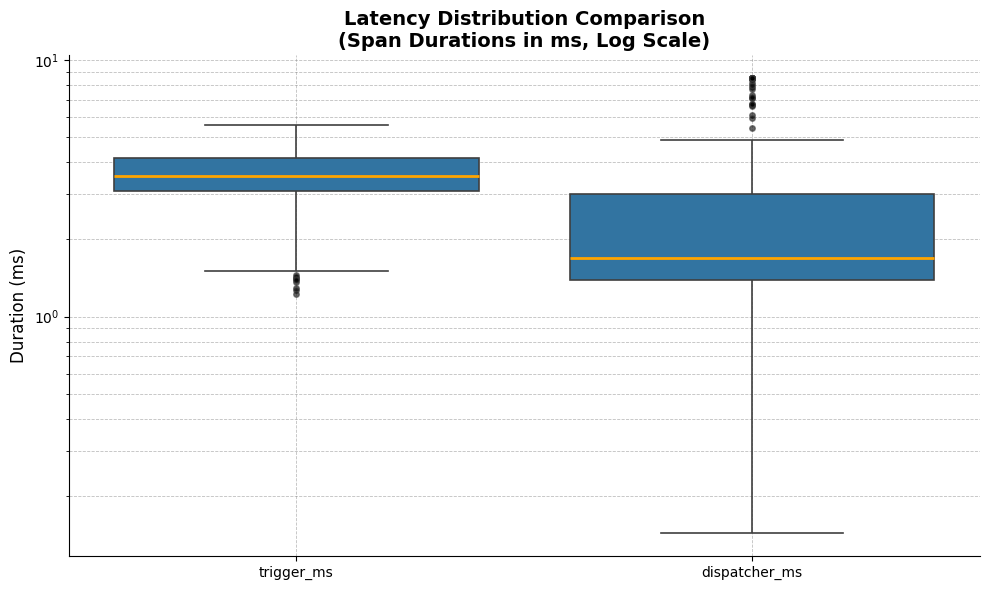

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate 95th percentile for each duration column
p95_span1 = np.percentile(df['trigger_ms'], 95)
p95_span6 = np.percentile(df['dispatcher_ms'], 95)
p95_total = np.percentile(df['total_duration_ms'], 95)

# Filter rows by clipping durations at 95th percentile
df_filtered = df.copy()
df_filtered['trigger_ms'] = np.minimum(df['trigger_ms'], p95_span1)
df_filtered['dispatcher_ms'] = np.minimum(df['dispatcher_ms'], p95_span6)
df_filtered['total_duration_ms'] = np.minimum(df['total_duration_ms'], p95_total)

# Melt filtered data for seaborn, excluding 'total_duration_ms'
df_melted = df_filtered.melt(id_vars='traceID', 
                             value_vars=['trigger_ms', 'dispatcher_ms'],  # exclude total_duration_ms here
                             var_name='Span', value_name='Duration_ms')

plt.figure(figsize=(10,6))

# Create the boxplot with Seaborn and custom styling
sns.boxplot(x='Span', y='Duration_ms', data=df_melted,
            boxprops=dict(linewidth=1.2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            medianprops=dict(color='orange', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='black', markersize=4, alpha=0.6))

# Title and labels
plt.title('Latency Distribution Comparison\n(Span Durations in ms, Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Duration (ms)', fontsize=12)

# Log scale for y-axis
plt.yscale('log')

# Grid lines with dashed style and light gray color
plt.grid(True, which='both', linestyle='--', linewidth=0.6, color='gray', alpha=0.5)

# Remove top and right spines for cleaner look
sns.despine()

plt.tight_layout()
plt.show()
